# K-Means Clustering Algorithm

## 1️⃣ What is K-Means?

- **K-Means** is an **unsupervised machine learning algorithm** used to group similar data points into **K clusters**.
- Each cluster is represented by a **centroid** (mean of points).
- The goal is to **minimize intra-cluster distance**. 

---

## 2️⃣ When is K-Means Used?

K-Means is commonly applied in: 

- 🛒 **Customer segmentation**
- 📊 **Market analysis**
- 🖼️ **Image compression**
- 📄 **Document grouping**
- 🔍 **Pattern discovery**

---

## 3️⃣ Key Idea (One Line)

> **Group data so that points in the same cluster are as close as possible, and points in different clusters are far apart.**

---

## 4️⃣ Internal Working of K-Means (Core Part)

K-Means works in an **iterative optimization loop**. 

### 🔁 Step-by-Step Internal Process

#### 🔹 Step 1: Choose number of clusters (K)

- **K is predefined** by the user.
- Common methods to choose K:
  - **Elbow method**
  - **Silhouette score**

---

#### 🔹 Step 2: Initialize centroids

- **Randomly select K data points** as initial centroids  
  (or use **K-Means++** for smarter initialization).

**Example:**

```
Centroid₁ = random point
Centroid₂ = random point
...
Centroidₖ = random point
```

---

#### 🔹 Step 3: Assignment step (Cluster allocation)

For each data point:

1. Calculate distance to **all centroids**
2. Assign point to **nearest centroid**

**📐 Distance (usually Euclidean):**

$$
d(x, c) = \sqrt{(x_1 - c_1)^2 + (x_2 - c_2)^2}
$$

This creates **K clusters**.

---

#### 🔹 Step 4: Update step (Centroid recalculation)

For each cluster:

- Compute **new centroid** as the **mean** of all points in that cluster

$$
\text{New Centroid} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

> **This is why it's called K-Means.**

---

#### 🔹 Step 5: Convergence check

**Repeat Step 3 & 4** until:

- ✅ Centroids **stop changing** OR
- ✅ **Maximum iterations** reached OR
- ✅ Change is **very small**

---

## 🔄 Optimization Objective (What K-Means Minimizes)

K-Means minimizes **Inertia** (also called **Within-Cluster Sum of Squares - WCSS**):

$$
\text{Inertia} = \sum_{i=1}^{n} \|x_i - \mu_{\text{cluster}}\|^2
$$

Where:
- $x_i$ = data point
- $\mu_{\text{cluster}}$ = centroid of the cluster

**Lower inertia → better clustering**

> **Used in Elbow Method** to determine optimal K

---

## 📌 Summary

| Step | Action | Purpose |
|------|--------|---------|
| **1** | Choose K | Define number of clusters |
| **2** | Initialize centroids | Starting point for algorithm |
| **3** | Assign points to nearest centroid | Form clusters |
| **4** | Update centroids | Recalculate cluster centers |
| **5** | Check convergence | Determine if optimization is complete |

---

## 🎯 Key Takeaways

- K-Means is **simple** and **fast**
- Works well with **spherical clusters**
- Sensitive to **initial centroid placement** (use K-Means++)
- Requires **K to be predefined**
- Minimizes **intra-cluster variance**

---


In [11]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv(
    r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\placement.csv")

In [13]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [14]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


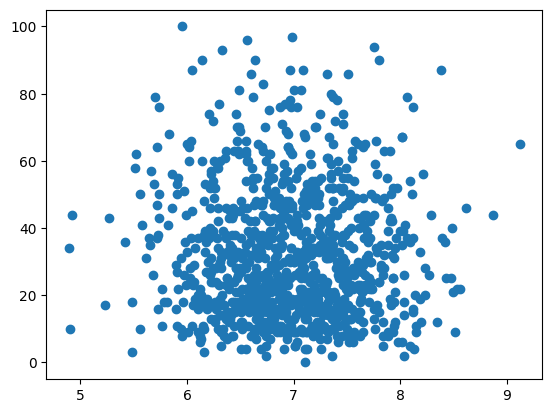

In [22]:
plt.scatter(df['cgpa'], df['placement_exam_marks'])

In [17]:
x = df.iloc[: , 0:2].values
y = df.iloc[: , -1].values

In [18]:
x

array([[ 7.19, 26.  ],
       [ 7.46, 38.  ],
       [ 7.54, 40.  ],
       ...,
       [ 4.89, 34.  ],
       [ 8.62, 46.  ],
       [ 4.9 , 10.  ]], shape=(1000, 2))

In [24]:
from sklearn.cluster import KMeans

In [26]:
wcss = []
for i in range(1 , 20):
    km = KMeans(n_clusters=i)
    km.fit_predict(x)
    wcss.append(km.inertia_)

In [27]:
wcss

[366001.3258624001,
 115745.65343327867,
 56426.277203913975,
 35481.266871531334,
 23095.853353945517,
 18348.83915875097,
 13365.872321865358,
 10534.974199899894,
 7366.535522678842,
 5964.851987925673,
 5187.0195945796195,
 4743.834429896156,
 3966.5126019057607,
 3960.3301214237777,
 2963.054029786811,
 2883.486284677472,
 2372.2647091476474,
 2333.5828426630173,
 1905.2557789749706]

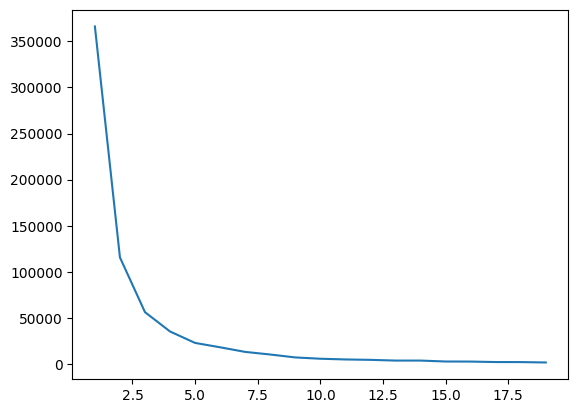

In [28]:
plt.plot(range(1 , 20) , wcss)

In [29]:
km = KMeans(n_clusters=9)
y_pred = km.fit_predict(x)
y_pred

array([8, 0, 3, 7, 1, 5, 7, 0, 0, 4, 1, 7, 1, 8, 3, 5, 5, 5, 8, 8, 3, 0,
       6, 7, 7, 6, 7, 3, 5, 1, 1, 3, 7, 8, 7, 1, 1, 7, 5, 1, 4, 0, 2, 2,
       6, 7, 1, 3, 3, 8, 5, 8, 8, 0, 0, 1, 1, 5, 3, 0, 8, 4, 5, 8, 6, 8,
       8, 5, 8, 3, 1, 5, 5, 1, 7, 6, 1, 8, 1, 5, 3, 3, 1, 5, 0, 8, 5, 5,
       0, 1, 1, 7, 2, 8, 5, 0, 8, 6, 4, 5, 3, 8, 5, 5, 3, 1, 5, 7, 7, 5,
       8, 0, 1, 7, 4, 0, 5, 7, 6, 0, 3, 8, 6, 6, 8, 6, 0, 5, 8, 0, 6, 5,
       5, 2, 4, 3, 1, 6, 7, 7, 5, 5, 3, 0, 1, 8, 5, 7, 6, 6, 5, 1, 6, 7,
       6, 1, 0, 4, 6, 5, 7, 6, 4, 3, 0, 7, 6, 3, 0, 1, 0, 0, 3, 3, 5, 8,
       8, 3, 0, 3, 8, 3, 4, 5, 0, 8, 2, 7, 6, 7, 5, 7, 0, 1, 0, 3, 0, 8,
       3, 8, 5, 1, 3, 6, 7, 3, 8, 1, 1, 0, 5, 1, 6, 5, 2, 5, 0, 1, 6, 7,
       1, 5, 4, 7, 5, 1, 5, 5, 1, 1, 1, 0, 0, 3, 0, 6, 0, 6, 4, 1, 0, 5,
       3, 6, 3, 2, 8, 6, 3, 6, 1, 3, 6, 4, 2, 7, 3, 4, 7, 7, 6, 7, 7, 6,
       8, 6, 6, 2, 5, 1, 1, 5, 6, 7, 7, 0, 3, 1, 1, 3, 6, 5, 3, 4, 2, 6,
       6, 5, 5, 7, 4, 1, 3, 7, 1, 2, 5, 0, 3, 1, 6,

In [30]:
x[y_pred== 3, 1]

array([40., 43., 47., 46., 44., 46., 42., 43., 44., 46., 44., 46., 47.,
       46., 47., 41., 42., 48., 43., 48., 40., 45., 42., 44., 44., 48.,
       47., 41., 44., 44., 44., 45., 48., 46., 40., 44., 41., 48., 47.,
       47., 46., 42., 40., 42., 41., 41., 47., 43., 48., 43., 45., 46.,
       46., 46., 46., 48., 42., 43., 47., 46., 44., 43., 48., 46., 44.,
       45., 48., 47., 40., 42., 41., 43., 43., 43., 45., 43., 48., 47.,
       47., 43., 42., 41., 45., 42., 43., 42., 48., 41., 47., 43., 43.,
       42., 42., 42., 44., 41., 48., 44., 46., 41., 42., 48., 44., 46.])

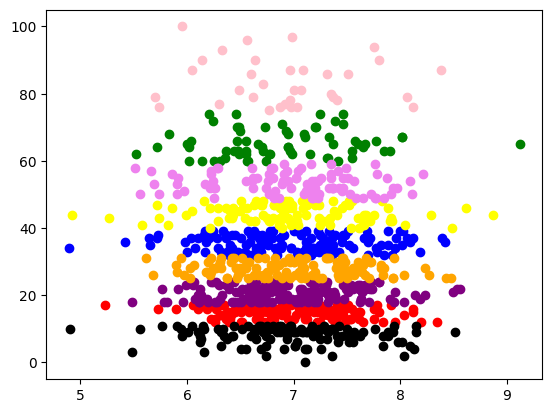

In [34]:
plt.scatter(x[y_pred == 0, 0], x[y_pred == 0, 1], color='blue')
plt.scatter(x[y_pred == 1, 0], x[y_pred == 1, 1], color='red')
plt.scatter(x[y_pred == 2, 0], x[y_pred == 2, 1], color='green')
plt.scatter(x[y_pred == 3, 0],x[y_pred == 3,1],color='yellow')
plt.scatter(x[y_pred == 4, 0],x[y_pred == 4,1],color='pink')
plt.scatter(x[y_pred == 5, 0],x[y_pred == 5,1],color='purple')
plt.scatter(x[y_pred == 6, 0],x[y_pred == 6,1],color='violet')
plt.scatter(x[y_pred == 7, 0],x[y_pred == 7,1],color='black')
plt.scatter(x[y_pred == 8, 0],x[y_pred == 8,1],color='orange')
